Sistema Predittivo di Scouting e Valutazione per la Nazionale Italiana di Pallavolo.
Lo scopo è quello di dare un voto da 1 a 10 ad ogni atleta che viene presentata, dove 1 è pessima per la nazionale e 10 è perfetta per la nazionale.

Creiamo un datest inventato che descriva le caratteristiche di 500 atlete. 6 caratteristiche fisiche: età (int), altezza, peso, indice di massa muscolare, altezza massima a muro ed altezza massima in attacco. 3 mentali visualizzate in una scala da 1 a 10: gestione della pressione, sacrificio e motivazione. 7 di esperienza: anni in A1, punti per set, percentuale dell'efficienza dell'attacco, percentuale di ricezioni perfette, punti a muro, ace per set, errori per set.

In [111]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_atleti = 800

# Codici identificativi "ID + 6 cifre" unici
numeri_casuali = np.random.randint(100000, 1000000, size=n_atleti)
id_atleti = [f"ID{num}" for num in numeri_casuali]

# Caratteristiche fisiche
eta = np.random.randint(18, 35, size=n_atleti)                         # Età attuale (18-34 anni)
altezza_cm = np.random.normal(loc=185, scale=7, size=n_atleti)         # Altezza (cm)
reach_attacco_cm = altezza_cm + np.random.normal(loc=130, scale=5, size=n_atleti)
reach_muro_cm = altezza_cm + np.random.normal(loc=115, scale=5, size=n_atleti)
peso_kg = np.random.normal(loc=74, scale=8, size=n_atleti)             # Peso in kg
indice_massa_corporea = peso_kg / ((altezza_cm / 100) ** 2)

# Caratteristiche mentali
gestione_pressione = np.random.uniform(3.0, 10.0, size=n_atleti)
sacrificio = np.random.uniform(4.0, 10.0, size=n_atleti)
motivazione = np.random.uniform(5.0, 10.0, size=n_atleti)

# Esperienza
anni_esperienza_a1 = np.random.randint(0, 12, size=n_atleti)
punti_per_set = np.random.uniform(1.0, 6.5, size=n_atleti)
efficienza_attacco_percentuale = np.random.uniform(15.0, 55.0, size=n_atleti) # in %
ricezione_perfetta_percentuale = np.random.uniform(10.0, 50.0, size=n_atleti) # in %
muri_punto_per_set = np.random.uniform(0.1, 1.2, size=n_atleti)
ace_per_set = np.random.uniform(0.05, 0.6, size=n_atleti)
errori_punto_per_set = np.random.uniform(0.5, 2.5, size=n_atleti)

# Voto dell'atleta con malus errori
punteggio_grezzo = (
    (reach_attacco_cm - 280) * 0.10 +
    efficienza_attacco_percentuale * 0.40 +
    ricezione_perfetta_percentuale * 0.35 +
    muri_punto_per_set * 1.0 +
    gestione_pressione * 0.65 +
    sacrificio * 0.30 -
    errori_punto_per_set * 0.8
)

# Normalizziamo il voto finale tra 1.0 e 10.0
voto_nazionale = np.clip(punteggio_grezzo / 4.0, 1.0, 10.0)
voto_nazionale = np.round(voto_nazionale, 1)


tabella_volley_pro = pd.DataFrame({
    'Atleta_ID': id_atleti,
    'Eta': eta,
    'Altezza_cm': np.round(altezza_cm, 1),
    'Reach_Attacco_cm': np.round(reach_attacco_cm, 1),
    'Reach_Muro_cm': np.round(reach_muro_cm, 1),
    'IMC': np.round(indice_massa_corporea, 2),
    'Gestione_Pressione': np.round(gestione_pressione, 1),
    'Sacrificio': np.round(sacrificio, 1),
    'Anni_Exp_A1': anni_esperienza_a1,
    'Punti_Set': np.round(punti_per_set, 2),
    'Efficienza_Attacco_Pct': np.round(efficienza_attacco_percentuale, 1),
    'Ricezione_Perfetta_Pct': np.round(ricezione_perfetta_percentuale, 1),
    'Muri_Set': np.round(muri_punto_per_set, 2),
    'Ace_Set': np.round(ace_per_set, 2),
    'Errori_Set': np.round(errori_punto_per_set, 2),
    'Voto_Nazionale': voto_nazionale
})


print(f"Numero totale di atleti analizzati: {len(tabella_volley_pro)}")
display(tabella_volley_pro.head())

Numero totale di atleti analizzati: 800


,Atleta_ID,Eta,Altezza_cm,Reach_Attacco_cm,Reach_Muro_cm,IMC,Gestione_Pressione,Sacrificio,Anni_Exp_A1,Punti_Set,Efficienza_Attacco_Pct,Ricezione_Perfetta_Pct,Muri_Set,Ace_Set,Errori_Set,Voto_Nazionale
0,ID221958,26,174.9,304.8,292.6,28.36,7.8,8.3,1,5.02,43.8,49.8,1.09,0.31,1.71,10.0
1,ID771155,24,169.6,298.1,280.0,27.32,7.6,9.2,6,1.22,40.8,26.0,0.24,0.18,1.47,8.5
2,ID231932,18,188.1,322.1,301.0,24.08,3.3,4.8,10,1.52,28.3,34.6,1.01,0.16,0.71,7.9
3,ID465838,20,181.5,303.4,295.0,19.21,5.6,9.2,5,1.04,45.2,24.6,0.55,0.28,1.06,8.8
4,ID359178,30,177.9,302.6,297.7,19.94,9.9,7.6,9,1.84,40.9,25.7,1.19,0.47,2.28,8.9


Train, test e normalizzazione dei dati


In [112]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader

features = tabella_volley_pro.drop(columns=['Atleta_ID', 'Voto_Nazionale']) # escludo id e voto
output = tabella_volley_pro['Voto_Nazionale']

# creo train e test
dati_divisi = train_test_split(features, output, test_size=0.2, random_state=42, shuffle = False)
X_train = dati_divisi[0]
X_test = dati_divisi[1]
y_train = dati_divisi[2]
y_test = dati_divisi[3]

# normalizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# creo batch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

try:
    # Verifichiamo che i DataLoader esistano nella memoria di Colab
    assert 'train_loader' in globals() and 'test_loader' in globals(), "I DataLoader non sono stati trovati!"

    # Controlliamo che le dimensioni siano corrette (80% di 800 = 640, 20% = 160)
    num_train = len(train_loader.dataset)
    num_test = len(test_loader.dataset)

    assert num_train == 640, f"Attenzione: il training set ha {num_train} elementi invece di 640."
    assert num_test == 160, f"Attenzione: il test set ha {num_test} elementi invece di 160."

    print("Tutto ok")
    print(f"-> Atleti pronti per lo studio (Train): {num_train}")
    print(f"-> Atleti pronti per l'esame (Test): {num_test}")
    print(f"-> Dimensione dei batch: {train_loader.batch_size}")

except AssertionError as errore:
    print(f"{errore}")

Tutto ok
-> Atleti pronti per lo studio (Train): 640
-> Atleti pronti per l'esame (Test): 160
-> Dimensione dei batch: 32


Modello e loss function

In [113]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# 1. Architettura
class ModelloVolleyNazPotenziato(nn.Module):
    def __init__(self, input_dim):
        super(ModelloVolleyNazPotenziato, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)   # Più neuroni in ingresso
        self.dropout1 = nn.Dropout(0.2) # senza overfittava
        self.layer2 = nn.Linear(64, 32)  # Strato intermedio
        self.dropout2 = nn.Dropout(0.2)
        self.layer3 = nn.Linear(32, 16)  # Terzo strato
        self.output = nn.Linear(16, 1)  # Ultimo strato

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = self.dropout1(x)
        x = F.relu(self.layer2(x))
        x = self.dropout2(x)
        x = F.relu(self.layer3(x))
        x = self.output(x)
        return x

input_dimensione = X_train_scaled.shape[1]
modello = ModelloVolleyNazPotenziato(input_dimensione)
loss_fun = nn.MSELoss()
optimizer = optim.Adam(modello.parameters(), lr=0.0005, weight_decay=1e-4)

In [114]:
n_epoch = 500

for epoch in range(n_epoch):
    modello.train()
    perdita_totale_epoca = 0.0

    for batch_dati in train_loader:
        inputs = batch_dati[0]
        targets = batch_dati[1]

        optimizer.zero_grad()
        pred = modello(inputs)
        loss = loss_fun(pred, targets)
        loss.backward()
        optimizer.step()

        train_loss = perdita_totale_epoca + loss.item()

    # Stampiamo i progressi ogni 50 epoche
    if (epoch + 1) %50 == 0:
        print(f"Epoca [{epoch + 1}/{n_epoch}] - Train loss: {train_loss:.6f}")


Epoca [50/500] - Train loss: 0.981505
Epoca [100/500] - Train loss: 0.924908
Epoca [150/500] - Train loss: 0.844295
Epoca [200/500] - Train loss: 0.903244
Epoca [250/500] - Train loss: 0.482623
Epoca [300/500] - Train loss: 0.569410
Epoca [350/500] - Train loss: 0.395400
Epoca [400/500] - Train loss: 0.157320
Epoca [450/500] - Train loss: 0.167739
Epoca [500/500] - Train loss: 0.110879


In [115]:

modello.eval()
errore_test_totale = 0.0

with torch.no_grad():
    for batch_dati in test_loader:
        inputs_test = batch_dati[0]
        targets_test = batch_dati[1]

        previsioni_test = modello(inputs_test)

        loss_test = loss_fun(previsioni_test, targets_test)
        errore_test_totale = errore_test_totale + loss_test.item()

        if (epoch + 1) % 20 == 0:
          print(f"Epoca [{epoch + 1}/{n_epoch}] - Train loss: {train_loss:.6f} - Test loss: {errore_test_totale:.6f}")

# Calcoliamo la media dell'errore sul test set
errore_test_medio = errore_test_totale / len(test_loader)
errore_train_medio = train_loss / len(train_loader)

print(f"Errore medio sul Train Set : {errore_train_medio:.4f}")
print(f"Errore medio sul Test Set: {errore_test_medio:.4f} ")

Epoca [500/500] - Train loss: 0.110879 - Test loss: 0.034857
Epoca [500/500] - Train loss: 0.110879 - Test loss: 0.069742
Epoca [500/500] - Train loss: 0.110879 - Test loss: 0.085226
Epoca [500/500] - Train loss: 0.110879 - Test loss: 0.111622
Epoca [500/500] - Train loss: 0.110879 - Test loss: 0.181760
Errore medio sul Train Set : 0.0055
Errore medio sul Test Set: 0.0364 


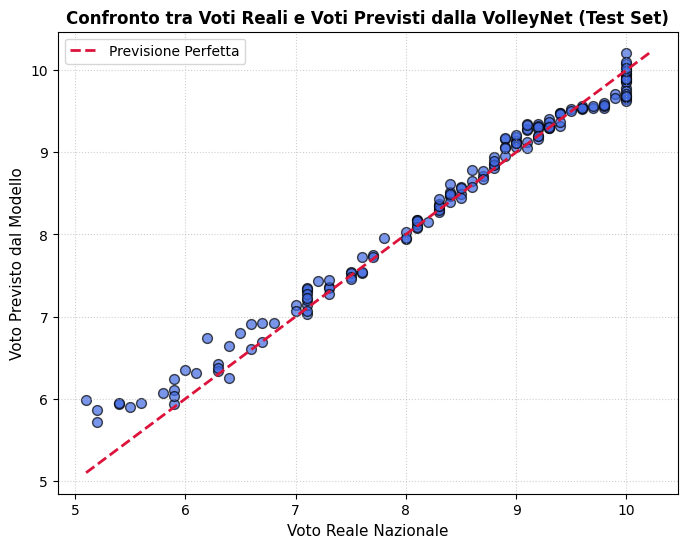

In [116]:
import matplotlib.pyplot as plt

# 1. Raccogliamo tutti i dati e le previsioni del test set
tutti_i_reali = []
tutte_le_previsioni = []

modello.eval()
with torch.no_grad():
    for batch_dati in test_loader:
        inputs_test = batch_dati[0]
        targets_test = batch_dati[1]

        previsioni_test = modello(inputs_test)

        # Salviamo i valori convertendoli in liste Python (portandoli dalla GPU/tensore alla CPU)
        tutti_i_reali.extend(targets_test.squeeze().tolist())
        tutte_le_previsioni.extend(previsioni_test.squeeze().tolist())

plt.figure(figsize=(8, 6))
plt.scatter(tutti_i_reali, tutte_le_previsioni, color='royalblue', alpha=0.7, edgecolors='k', s=50)

valore_min = min(min(tutti_i_reali), min(tutte_le_previsioni))
valore_max = max(max(tutti_i_reali), max(tutte_le_previsioni))
plt.plot([valore_min, valore_max], [valore_min, valore_max], color='crimson', linestyle='--', linewidth=2, label='Previsione Perfetta')

plt.title('Confronto tra Voti Reali e Voti Previsti dalla VolleyNet (Test Set)', fontsize=12, fontweight='bold')
plt.xlabel('Voto Reale Nazionale', fontsize=11)
plt.ylabel('Voto Previsto dal Modello', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [117]:
import torch
import pandas as pd

modello.eval()

# Scaliamo tutte le feature e facciamo fare le previsioni al modello potenziato
features_complete_scaled = scaler.transform(features)
with torch.no_grad():
    tensor_completo = torch.tensor(features_complete_scaled, dtype=torch.float32)
    previsioni = modello(tensor_completo)

# 3. Inseriamo il voto previsto nella tabella e arrotondiamolo a 1 decimale
tabella_volley_pro['Voto_Previsto'] = previsioni.squeeze().tolist()
tabella_volley_pro['Voto_Previsto'] = tabella_volley_pro['Voto_Previsto'].round(1)
tabella_volley_pro['Voto_Previsto'] = tabella_volley_pro['Voto_Previsto'].clip(lower=1.0, upper=10.0)

# 4. Associamo le frasi di giudizio anche al voto previsto usando le stesse soglie
soglie_voti = [0, 2.0, 4.0, 6.0, 7.5, 9.0, 10.0]
frasi_giudizio = [
    'Pessima per la nazionale',
    'Insufficiente',
    'Sufficiente / Da monitorare',
    'Buona / Ottima prospettiva',
    'Eccellente / Titolare',
    'Perfetta / Fuoriclasse'
]

tabella_volley_pro['Giudizio_Previsto'] = pd.cut(
    tabella_volley_pro['Voto_Previsto'],
    bins=soglie_voti,
    labels=frasi_giudizio,
    include_lowest=True
)

tabella_volley_pro['Voto_Previsto'] = tabella_volley_pro['Voto_Previsto'].clip(lower=1.0, upper=10.0)

# 5. Ordiniamo dal voto previsto più alto al più basso e prendiamo i top 10
top_10 = tabella_volley_pro.sort_values(by='Voto_Previsto', ascending=False).head(10)
print("TOP 10:\n")

for indice, riga in top_10.iterrows():
    print(f"Atleta: {riga['Atleta_ID']}  -->  Voto Reale: {riga['Voto_Nazionale']}  |  Voto AI: {riga['Voto_Previsto']}  |  Giudizio: {riga['Giudizio_Previsto']}")

TOP 10:

Atleta: ID303196  -->  Voto Reale: 10.0  |  Voto AI: 10.0  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID535564  -->  Voto Reale: 10.0  |  Voto AI: 10.0  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID876997  -->  Voto Reale: 10.0  |  Voto AI: 10.0  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID427069  -->  Voto Reale: 10.0  |  Voto AI: 10.0  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID742612  -->  Voto Reale: 10.0  |  Voto AI: 10.0  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID229981  -->  Voto Reale: 10.0  |  Voto AI: 10.0  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID331915  -->  Voto Reale: 10.0  |  Voto AI: 10.0  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID712956  -->  Voto Reale: 10.0  |  Voto AI: 10.0  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID288751  -->  Voto Reale: 10.0  |  Voto AI: 10.0  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID339629  -->  Voto Reale: 10.0  |  Voto AI: 10.0  |  Giudizio: Perfetta / Fuoriclasse


In [131]:
voto_massimo = tabella_volley_pro['Voto_Nazionale'].max()
voto_minimo = tabella_volley_pro['Voto_Nazionale'].min()

atleti_migliori = tabella_volley_pro[tabella_volley_pro['Voto_Nazionale'] == voto_massimo]
atleti_peggiori = tabella_volley_pro[tabella_volley_pro['Voto_Nazionale'] == voto_minimo]

print(f"Numero di atleti che hanno raggiunto il valore più massimo: {len(atleti_migliori)}")
display(atleti_migliori)

print(f"Numero di atleti che hanno raggiunto il valore minimo: {len(atleti_peggiori)}")
display(atleti_peggiori)

atleti_azzeccati = tabella_volley_pro[abs(tabella_volley_pro['Voto_Nazionale'] - tabella_volley_pro['Voto_Previsto']) < 0.01]
print(f"Numero di atleti azzeccati da AI con scarto inferiore a 0.01: {len(atleti_azzeccati)}")
display(atleti_azzeccati)



#print(f"Il Voto Reale massimo registrato nel dataset è: {voto_massimo}")
#print(f"Numero di atleti che hanno raggiunto questo vertice: {len(atleti_top_assoluti)}\n")
#for indice, riga in atleti_migliori.iterrows():
#    print(f"Atleta: {riga['Atleta_ID']}  -->  Voto Reale: {riga['Voto_Nazionale']}  |  Voto VolleyNet: {riga['Voto_Previsto']}  |  Giudizio: {riga['Giudizio_Previsto']}")

Numero di atleti che hanno raggiunto il valore più massimo: 149


,Atleta_ID,Eta,Altezza_cm,Reach_Attacco_cm,Reach_Muro_cm,IMC,Gestione_Pressione,Sacrificio,Anni_Exp_A1,Punti_Set,Efficienza_Attacco_Pct,Ricezione_Perfetta_Pct,Muri_Set,Ace_Set,Errori_Set,Voto_Nazionale,Voto_Previsto,Giudizio_Previsto
0,ID221958,26,174.9,304.8,292.6,28.36,7.8,8.3,1,5.02,43.8,49.8,1.09,0.31,1.71,10.0,10.0,Perfetta / Fuoriclasse
6,ID210268,18,186.7,321.5,295.5,22.38,6.5,6.6,8,6.48,37.1,47.5,0.71,0.43,1.33,10.0,9.9,Perfetta / Fuoriclasse
8,ID154886,23,176.0,305.5,287.5,25.70,8.0,8.2,6,1.82,42.9,40.7,0.45,0.31,1.93,10.0,9.7,Perfetta / Fuoriclasse
11,ID187498,30,184.3,320.1,297.8,24.68,9.1,7.0,0,3.86,47.7,30.1,0.98,0.59,1.52,10.0,9.8,Perfetta / Fuoriclasse
20,ID421879,34,176.2,303.0,300.6,24.93,3.5,6.8,1,2.59,54.1,35.8,0.77,0.43,0.82,10.0,9.8,Perfetta / Fuoriclasse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,ID548345,21,190.0,318.8,310.6,19.50,9.0,9.9,3,1.06,52.9,19.2,0.51,0.18,0.90,10.0,9.7,Perfetta / Fuoriclasse
789,ID639773,24,183.2,328.1,293.7,21.73,4.8,8.9,9,4.26,40.4,44.0,0.56,0.52,1.35,10.0,9.9,Perfetta / Fuoriclasse
791,ID186188,18,189.3,317.7,305.6,21.11,3.9,5.3,2,4.14,54.4,47.1,0.48,0.35,1.75,10.0,10.0,Perfetta / Fuoriclasse
797,ID130355,31,197.9,322.2,317.0,22.29,4.6,9.5,0,3.36,46.8,46.2,1.11,0.42,2.46,10.0,10.0,Perfetta / Fuoriclasse


Numero di atleti che hanno raggiunto il valore minimo: 1


,Atleta_ID,Eta,Altezza_cm,Reach_Attacco_cm,Reach_Muro_cm,IMC,Gestione_Pressione,Sacrificio,Anni_Exp_A1,Punti_Set,Efficienza_Attacco_Pct,Ricezione_Perfetta_Pct,Muri_Set,Ace_Set,Errori_Set,Voto_Nazionale,Voto_Previsto,Giudizio_Previsto
514,ID562894,25,181.3,306.8,302.1,25.17,4.7,6.0,1,4.62,16.7,10.3,0.97,0.08,1.97,4.3,5.6,Sufficiente / Da monitorare


Numero di atleti azzeccati da AI con scarto inferiore a 0.01: 291


,Atleta_ID,Eta,Altezza_cm,Reach_Attacco_cm,Reach_Muro_cm,IMC,Gestione_Pressione,Sacrificio,Anni_Exp_A1,Punti_Set,Efficienza_Attacco_Pct,Ricezione_Perfetta_Pct,Muri_Set,Ace_Set,Errori_Set,Voto_Nazionale,Voto_Previsto,Giudizio_Previsto
0,ID221958,26,174.9,304.8,292.6,28.36,7.8,8.3,1,5.02,43.8,49.8,1.09,0.31,1.71,10.0,10.0,Perfetta / Fuoriclasse
4,ID359178,30,177.9,302.6,297.7,19.94,9.9,7.6,9,1.84,40.9,25.7,1.19,0.47,2.28,8.9,8.9,Eccellente / Titolare
9,ID237337,29,191.1,320.3,299.8,19.73,7.1,8.6,4,2.33,30.0,13.6,0.18,0.07,1.91,6.7,6.7,Buona / Ottima prospettiva
14,ID291335,28,174.3,309.2,282.4,23.60,5.7,7.1,3,3.17,23.1,30.7,0.79,0.14,0.97,7.2,7.2,Buona / Ottima prospettiva
16,ID141090,21,184.7,315.6,304.8,23.29,7.9,7.2,8,2.14,34.1,20.6,0.38,0.39,1.68,7.7,7.7,Eccellente / Titolare
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,ID126790,31,184.4,316.0,301.4,20.89,3.6,8.3,2,2.46,52.0,14.7,0.95,0.26,0.51,8.7,8.7,Eccellente / Titolare
788,ID587462,29,188.6,319.5,304.6,19.44,3.6,5.3,1,4.64,23.6,38.2,0.90,0.39,0.97,7.7,7.7,Eccellente / Titolare
791,ID186188,18,189.3,317.7,305.6,21.11,3.9,5.3,2,4.14,54.4,47.1,0.48,0.35,1.75,10.0,10.0,Perfetta / Fuoriclasse
795,ID890141,28,190.7,323.7,302.7,24.32,5.5,4.5,8,2.51,22.0,21.9,0.98,0.07,2.13,6.3,6.3,Buona / Ottima prospettiva
